In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.plot_style import apply_plot_style, wrap_labels

apply_plot_style()

In [ ]:
# Configurations

datadir = "/projects/standard/lenkne/oboiko/EJ/data/"
filepath = datadir + "rsei_weighted_disparity_ratios_huc12_{}.csv"
study_periods = ["2008_2012", "2013_2017", "2018_2022"]
clrs = ["#edf8b1", "#7fcdbb", "#2c7fb8"]

groups = [
    "Black or African American",
    "American Indian and Alaska Native",
    "Asian",
    "Hispanic or Latino",
    "Below Poverty",
]

analyses = [
    "using all HUC12 units",
    "using HUC12 units with non zero TOXCONC",
    "using 100 HUC12 units with the highest TOXCONC",
    "using 200 HUC12 units with the highest TOXCONC",
    "using HUC12 units within the 90th percentile TOXCONC",
    "Regional: Headwaters",
    "Regional: Gorge",
    "Regional: Driftless",
    "Regional: Working River",
    "Regional: Confluence",
    "Regional: Chickasaw",
    "Regional: Delta",
    "Regional: Lower Mississippi",
    "Regional: Gulf South",
]

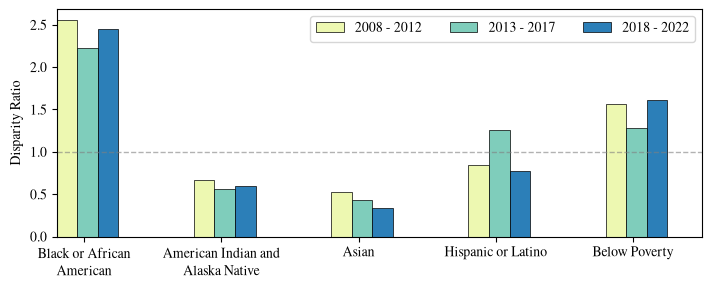

In [ ]:
for analysis in analyses[:1]:
    fig, ax = plt.subplots(figsize=(7, 2.8), layout="constrained")
    ax.axline((1, 1), slope=0, color="grey", ls="--", lw=1.0, alpha=0.6)
    position = 0
    for i, period in enumerate(study_periods):
        df = pd.read_csv(filepath.format(period), index_col=0)
        subset = df[df["analysis"].str.startswith(analysis)]
        subset = subset[subset["Group"].isin(groups)]
        subset[["Group", "Disparity Ratio"]].set_index("Group").plot(
            kind="bar",
            color=[clrs[i]],
            edgecolor="black",
            lw=0.5,
            ax=ax,
            legend=False,
            rot=0,
            position=position,
            width=0.15,
        )
        position -= 1
    # Customize plot properties
    ax.set_xticks(
        [
            (pos + (len(study_periods) - 1) * 0.2 / 2)
            for pos in range(len(subset["Group"]))
        ]
    )
    ax.set_xticklabels(subset["Group"])
    wrap_labels(ax, 20, axis="x")
    ax.set_ylabel("Disparity Ratio")
    ax.set_xlabel(None)
    c = [
        mpatches.Patch(facecolor=clrs[i], edgecolor="black", lw=0.5)
        for i in range(len(study_periods))
    ]
    ax.legend(c, [p.replace("_", " - ") for p in study_periods], ncol=3)
    plt.show()
    # fig.savefig(f'figures/weighted-dr-bar-{analysis}.pdf')
    fig.savefig(f"../figures/Figure 2.pdf")

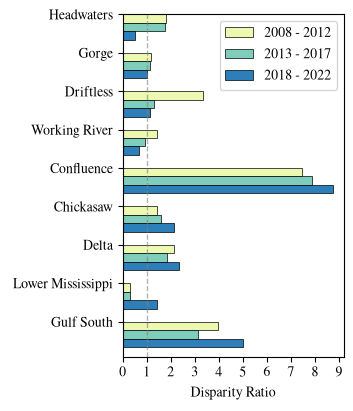

In [ ]:
# separate plot just for Black or African American (most impacted group), showing regional variations, north to south
# group = 'Black or African American'
for group in ["Black or African American"]:
    fig, ax = plt.subplots(figsize=(3.42, 4), layout="constrained")
    ax.axvline(1, color="grey", ls="--", lw=1.0, alpha=0.6)
    position = 0
    for i, period in enumerate(study_periods):
        df = pd.read_csv(filepath.format(period), index_col=0)
        subset = df[df["analysis"].str.startswith("Regional")]
        subset = subset[subset["Group"] == group]
        subset["Region"] = (
            subset["analysis"].str.split(",").str[0].str.split(":").str[1]
        )
        subset[["Region", "Disparity Ratio"]].set_index("Region").plot(
            kind="barh",
            color=[clrs[i]],
            edgecolor="black",
            lw=0.5,
            ax=ax,
            legend=False,
            rot=0,
            position=position,
            width=0.22,
        )
        position -= 1
    ax.invert_yaxis()
    ax.set_xlabel("Disparity Ratio")
    ax.set_ylabel(None)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    c = [
        mpatches.Patch(facecolor=clrs[i], edgecolor="black", lw=0.5)
        for i in range(len(study_periods))
    ]
    ax.legend(c, [p.replace("_", " - ") for p in study_periods])
    plt.show()
    # fig.savefig(f'figures/weighted-dr-barh-regional-{group}.pdf')
    fig.savefig(f"../figures/Figure 3.pdf")

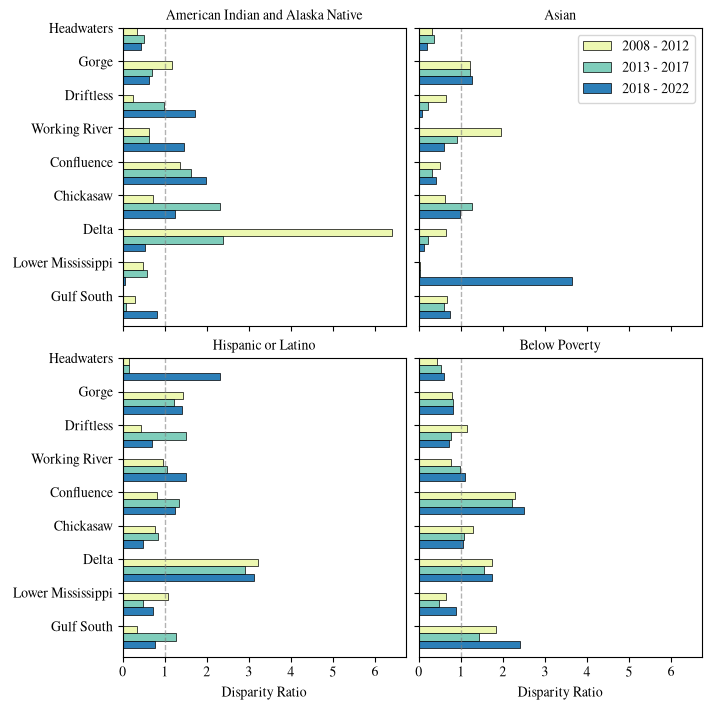

In [ ]:
# Create a 2x2 grid (adjust nrows/ncols if you have more/fewer than 4 groups)
fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(7, 7), layout="constrained", sharey=True, sharex=True
)
axes = axes.flatten()  # Flatten the 2D array to iterate easily
for idx, group in enumerate(groups[1:]):
    ax = axes[idx]  # Select the specific subplot for this group
    ax.axvline(1, color="grey", ls="--", lw=1.0, alpha=0.6)
    position = 0
    for i, period in enumerate(study_periods):
        df = pd.read_csv(filepath.format(period), index_col=0)
        subset = df[df["analysis"].str.startswith("Regional")]
        subset = subset[subset["Group"] == group]
        subset["Region"] = (
            subset["analysis"].str.split(",").str[0].str.split(":").str[1]
        )
        subset[["Region", "Disparity Ratio"]].set_index("Region").plot(
            kind="barh",
            color=[clrs[i]],
            edgecolor="black",
            lw=0.5,
            ax=ax,
            legend=False,
            rot=0,
            position=position,
            width=0.22,
        )
        position -= 1
    ax.invert_yaxis()
    ax.set_title(group)  # Added title to identify each group
    ax.set_xlabel("Disparity Ratio")
    ax.set_ylabel(None)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    c = [
        mpatches.Patch(facecolor=clrs[i], edgecolor="black", lw=0.5)
        for i in range(len(study_periods))
    ]
axes[1].legend(c, [p.replace("_", " - ") for p in study_periods])
plt.show()
# fig.savefig('figures/weighted-dr-barh-regional-all_groups.pdf')
fig.savefig("../figures/Figure S5.pdf")